In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("netflix_titles_cleaned.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

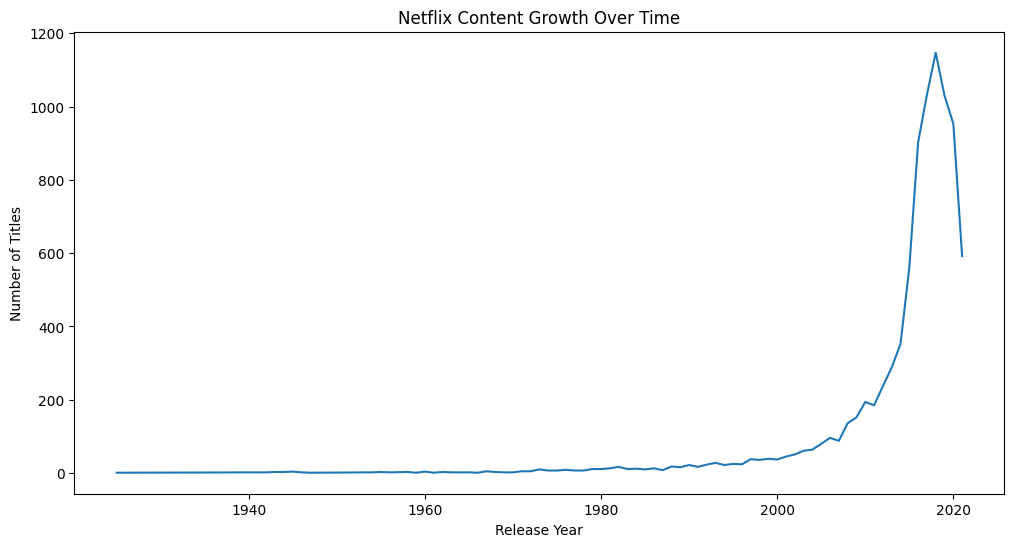

In [4]:
content_growth = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(12,6))
plt.plot(content_growth.index, content_growth.values)

plt.title("Netflix Content Growth Over Time")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()

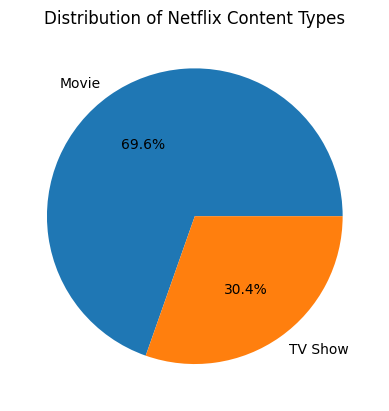

In [5]:
df['type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Distribution of Netflix Content Types")
plt.ylabel("")
plt.show()

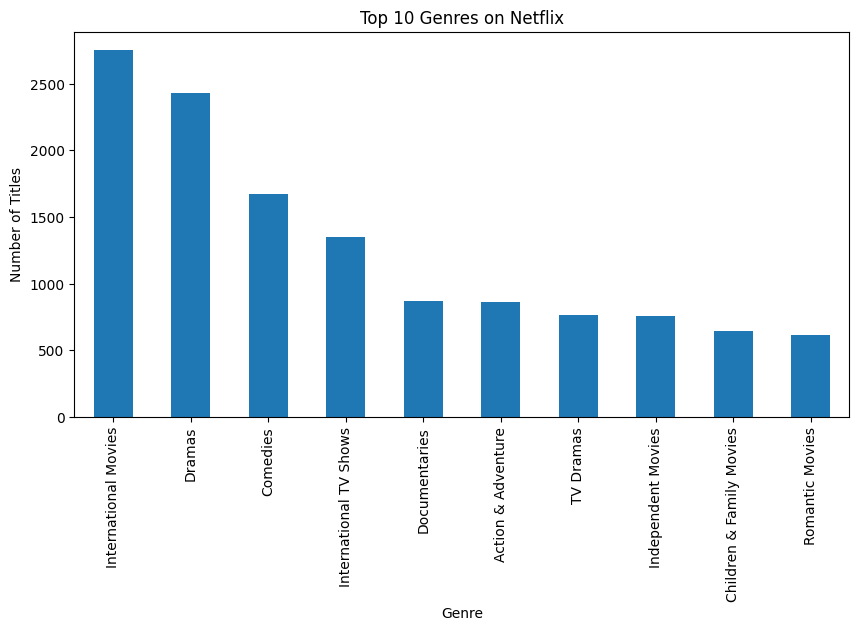

In [6]:
genres = df['listed_in'].str.split(', ').explode()

genres.value_counts().head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Number of Titles")
plt.show()

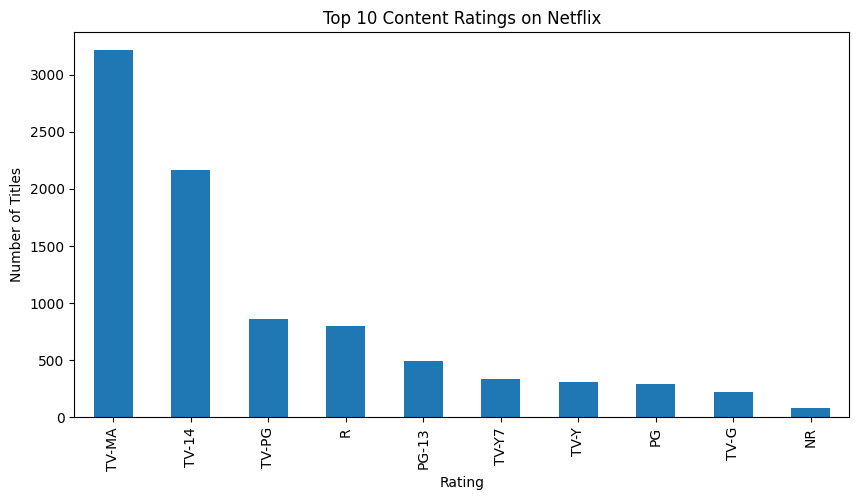

In [7]:
df['rating'].value_counts().head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top 10 Content Ratings on Netflix")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.show()

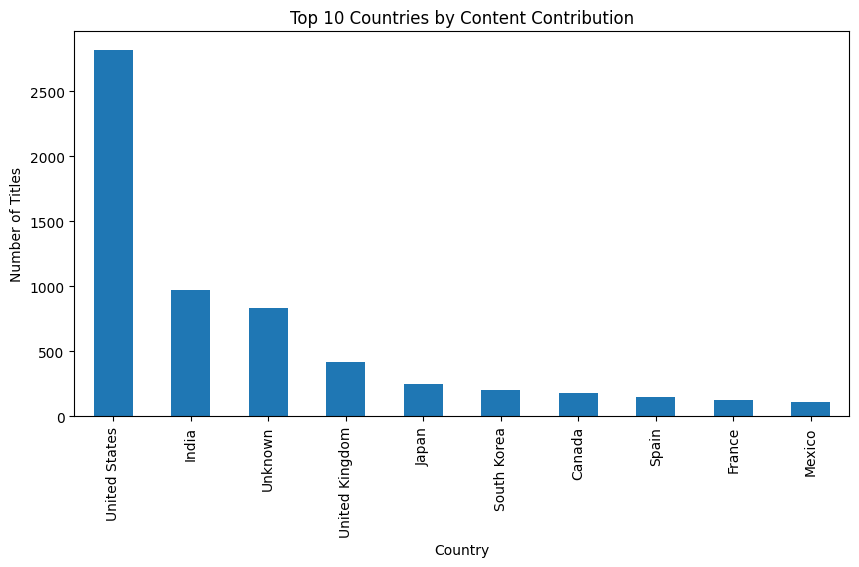

In [8]:
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_countries.plot(kind='bar')

plt.title("Top 10 Countries by Content Contribution")
plt.xlabel("Country")
plt.ylabel("Number of Titles")

plt.show()

In [9]:
def length_category(duration):
    if "min" in str(duration):
        mins = int(duration.split()[0])

        if mins < 60:
            return "Short"
        elif mins <= 120:
            return "Medium"
        else:
            return "Long"

    return "TV Show"

df["Content_Length_Category"] = df["duration"].apply(length_category)

df["Content_Length_Category"].value_counts()

Content_Length_Category
Medium     4528
TV Show    2679
Long       1142
Short       458
Name: count, dtype: int64

In [10]:
# Content Age
current_year = 2026
df["Content_Age"] = current_year - df["release_year"]

# Decade Feature
df["Decade"] = (df["release_year"] // 10 * 10).astype(str) + "s"

# Genre Count
df["Genre_Count"] = df["listed_in"].str.split(", ").apply(len)

# View the new columns
print(df[["Content_Age", "Decade", "Genre_Count"]].head())

   Content_Age Decade  Genre_Count
0            6  2020s            1
1            5  2020s            3
2            5  2020s            3
3            5  2020s            2
4            5  2020s            3


In [11]:
df.to_csv("netflix_titles_featured.csv", index=False)

print("Feature engineered dataset saved successfully!")

Feature engineered dataset saved successfully!
